# 01 — Understanding the Olist Dataset

## Objectif du notebook

Ce notebook sert à comprendre les données Olist avant toute étape de nettoyage, de modélisation ou de machine learning.

Objectifs :

- identifier les tables disponibles 
- comprendre la volumétrie 
- inspecter les colonnes 
- analyser les types 
- détecter les valeurs manquantes 
- comprendre les clés et les relations entre tables 
- analyser les dates de commande et de livraison 
- étudier les retards de livraison 
- observer le lien entre retard et satisfaction client 
- préparer la problématique métier et le cas d’usage ML

Important : ce notebook ne nettoie pas encore les données. Il sert à comprendre ce qu’il faudra nettoyer ensuite. Pas d'embrouille !

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
PROJECT_ROOT = Path("..")
DATA_SOURCE = PROJECT_ROOT / "data" / "source"

DATA_SOURCE

WindowsPath('../data/source')

In [3]:
files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

In [4]:
missing_files = []

for filename in files.values():
    path = DATA_SOURCE / filename
    if not path.exists():
        missing_files.append(filename)

if missing_files:
    raise FileNotFoundError(
        "Fichiers manquants dans data/source/ :\n" + "\n".join(missing_files)
    )

print("Tous les fichiers sont présents.")

Tous les fichiers sont présents.


In [5]:
data = {}

for name, filename in files.items():
    path = DATA_SOURCE / filename
    data[name] = pd.read_csv(path)
    print(f"{name:20s} -> {data[name].shape[0]:>8,} lignes | {data[name].shape[1]:>3} colonnes")

customers            ->   99,441 lignes |   5 colonnes
geolocation          -> 1,000,163 lignes |   5 colonnes
orders               ->   99,441 lignes |   8 colonnes
order_items          ->  112,650 lignes |   7 colonnes
payments             ->  103,886 lignes |   5 colonnes
reviews              ->   99,224 lignes |   7 colonnes
products             ->   32,951 lignes |   9 colonnes
sellers              ->    3,095 lignes |   4 colonnes
category_translation ->       71 lignes |   2 colonnes


## 2. Aperçu des premières lignes

 affichage des premières lignes de chaque table.

Objectif :

- comprendre rapidement le contenu de chaque table 
- repérer les identifiants 
- voir les colonnes métier importantes 
- commencer à comprendre les relations possibles entre les tables

In [6]:
for name, df in data.items():
    print("=" * 100)
    print(name.upper())
    display(df.head())

CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


ORDERS


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


SELLERS


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


CATEGORY_TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## 3. Résumé global des tables

Tableau de synthèse avec :

- le nom de chaque table 
- le nombre de lignes 
- le nombre de colonnes 
- la liste des colonnes

Cette étape permet d'avoir une vue d'ensemble du dataset.

In [8]:
tables_summary = []

for name, df in data.items():
    tables_summary.append({
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "column_names": ", ".join(df.columns)
    })

tables_summary_df = pd.DataFrame(tables_summary)
tables_summary_df.sort_values("rows", ascending=False)

,table,rows,columns,column_names
1,geolocation,1000163,5,"geolocation_zip_code_prefix, geolocation_lat, ..."
3,order_items,112650,7,"order_id, order_item_id, product_id, seller_id..."
4,payments,103886,5,"order_id, payment_sequential, payment_type, pa..."
0,customers,99441,5,"customer_id, customer_unique_id, customer_zip_..."
2,orders,99441,8,"order_id, customer_id, order_status, order_pur..."
5,reviews,99224,7,"review_id, order_id, review_score, review_comm..."
6,products,32951,9,"product_id, product_category_name, product_nam..."
7,sellers,3095,4,"seller_id, seller_zip_code_prefix, seller_city..."
8,category_translation,71,2,"product_category_name, product_category_name_e..."


### Premières observations

Le dataset contient 9 tables.

Les tables principales semblent être :

- `orders`, qui contient les commandes 
- `customers`, qui contient les informations clients 
- `order_items`, qui détaille les produits présents dans les commandes 
- `payments`, qui contient les informations de paiement 
- `reviews`, qui contient les notes et commentaires clients

Les tables `products`, `sellers`, `geolocation` et `category_translation` apportent des informations complémentaires sur les produits, les vendeurs, les localisations et les catégories.

La table `geolocation` est la plus volumineuse, mais elle ne représente pas des commandes, elle sert surtout à enrichir les données géographiques.

In [ ]:
## 4. Analyse des types de colonnes

 Types détectés.

Objectif :

- vérifier si les colonnes numériques sont bien reconnues 
- vérifier si les dates sont correctement typées 
- identifier les colonnes qui devront être converties plus tard

Pour info, str      = texte 
           int64    = nombre entier
           float64  = nombre décimal

au cas ou... 

In [9]:
for name, df in data.items():
    print("=" * 100)
    print(name.upper())
    display(df.dtypes.to_frame("dtype"))

CUSTOMERS


,dtype
customer_id,str
customer_unique_id,str
customer_zip_code_prefix,int64
customer_city,str
customer_state,str


GEOLOCATION


,dtype
geolocation_zip_code_prefix,int64
geolocation_lat,float64
geolocation_lng,float64
geolocation_city,str
geolocation_state,str


ORDERS


...

,dtype
product_id,str
product_category_name,str
product_name_lenght,float64
product_description_lenght,float64
product_photos_qty,float64
product_weight_g,float64
product_length_cm,float64
product_height_cm,float64
product_width_cm,float64


SELLERS


,dtype
seller_id,str
seller_zip_code_prefix,int64
seller_city,str
seller_state,str


CATEGORY_TRANSLATION


,dtype
product_category_name,str
product_category_name_english,str


## 5. Analyse des valeurs manquantes

identificatiob des colonnes qui contiennent des valeurs manquantes. Le but est de comprendre où il manque de la donnée et si c’est grave ou normal.

Objectif :

- repérer les colonnes incomplètes 
- distinguer les absences normales des vrais problèmes qualité 
- préparer les décisions de nettoyage pour l'étape Silver

In [12]:
missing_summary = []

for name, df in data.items():
    for col in df.columns:
        missing_count = df[col].isna().sum()
        missing_rate = missing_count / len(df)

        if missing_count > 0:
            missing_summary.append({
                "table": name,
                "column": col,
                "missing_count": missing_count,
                "missing_rate": round(missing_rate * 100, 2)
            })

missing_df = pd.DataFrame(missing_summary)

missing_df.sort_values(
    by=["missing_rate", "missing_count"],
    ascending=False
)

,table,column,missing_count,missing_rate
3,reviews,review_comment_title,87656,88.34
4,reviews,review_comment_message,58247,58.70
2,orders,order_delivered_customer_date,2965,2.98
5,products,product_category_name,610,1.85
6,products,product_name_lenght,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
1,orders,order_delivered_carrier_date,1783,1.79
0,orders,order_approved_at,160,0.16
9,products,product_weight_g,2,0.01


## 6. EDA rapide orientée métier

Cette section vise à comprendre rapidement les phénomènes principaux du dataset :

- période couverte 
- volume de commandes 
- statuts de commande 
- retards de livraison 
- impact du retard sur la satisfaction client 
- premières pistes pour le cas d’usage ML

In [13]:
orders = data["orders"].copy()
reviews = data["reviews"].copy()

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders[date_cols].head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [14]:
print("Première commande :", orders["order_purchase_timestamp"].min())
print("Dernière commande :", orders["order_purchase_timestamp"].max())

Première commande : 2016-09-04 21:15:19
Dernière commande : 2018-10-17 17:30:18


Le dataset couvre environ deux ans de commandes, ce qui est suffisant pour analyser l’activité, les délais de livraison et la satisfaction client.

In [15]:
orders_by_month = (
    orders
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
    .reset_index(name="orders_count")
)

orders_by_month

,order_purchase_timestamp,orders_count
0,2016-09-30,4
1,2016-10-31,324
2,2016-11-30,0
3,2016-12-31,1
4,2017-01-31,800
5,2017-02-28,1780
6,2017-03-31,2682
7,2017-04-30,2404
8,2017-05-31,3700
9,2017-06-30,3245


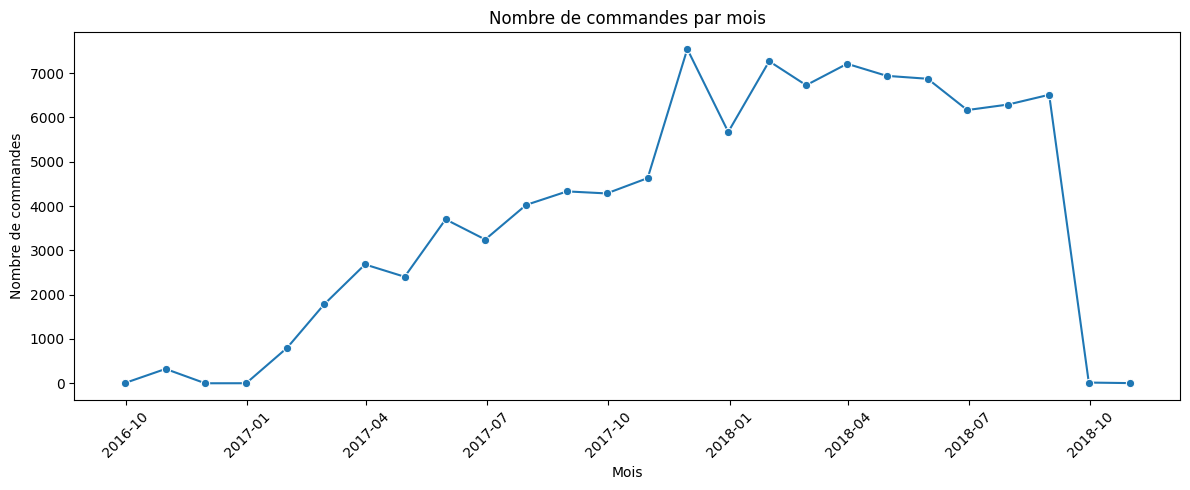

In [16]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=orders_by_month, x="order_purchase_timestamp", y="orders_count", marker="o")
plt.title("Nombre de commandes par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de commandes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
order_status = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

order_status.columns = ["order_status", "percentage"]
order_status

,order_status,percentage
0,delivered,97.02
1,shipped,1.11
2,canceled,0.63
3,unavailable,0.61
4,invoiced,0.32
5,processing,0.30
6,created,0.01
7,approved,0.00


La grande majorité des commandes sont livrées. Pour analyser les retards, on se concentrera donc sur les commandes avec le statut `delivered`, car elles possèdent une date de livraison réelle.

In [18]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

delivered_orders["delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.days

delivered_orders["late_delivery"] = delivered_orders["delay_days"] > 0

late_rate = delivered_orders["late_delivery"].mean()

print(f"Nombre de commandes livrées : {len(delivered_orders):,}")
print(f"Taux de commandes livrées en retard : {late_rate:.2%}")

Nombre de commandes livrées : 96,478
Taux de commandes livrées en retard : 6.77%


In [19]:
orders_reviews = delivered_orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

orders_reviews["negative_review"] = orders_reviews["review_score"] <= 2

impact_delay = orders_reviews.groupby("late_delivery").agg(
    orders_count=("order_id", "count"),
    avg_review_score=("review_score", "mean"),
    negative_review_rate=("negative_review", "mean")
).reset_index()

impact_delay["negative_review_rate"] = impact_delay["negative_review_rate"] * 100

impact_delay

,late_delivery,orders_count,avg_review_score,negative_review_rate
0,False,90445,4.289999,9.228813
1,True,6562,2.271025,60.957025


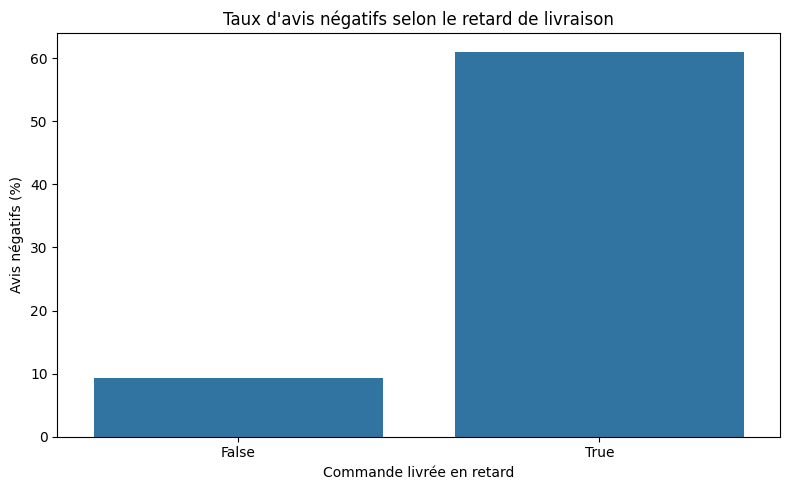

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=impact_delay, x="late_delivery", y="negative_review_rate")
plt.title("Taux d'avis négatifs selon le retard de livraison")
plt.xlabel("Commande livrée en retard")
plt.ylabel("Avis négatifs (%)")
plt.tight_layout()
plt.show()

Les commandes livrées en retard semblent fortement associées à une baisse de satisfaction client. Même si les retards ne représentent pas la majorité des commandes, leur impact sur les avis négatifs peut justifier un cas d’usage métier autour de la détection ou prédiction des commandes à risque.

## Conclusion de l'EDA rapide

Cette première exploration montre que le dataset Olist permet de construire un projet complet autour de la performance logistique et de la satisfaction client.

Les tables principales permettent de relier :

- les commandes 
- les clients 
- les produits 
- les vendeurs 
- les paiements 
- les avis clients

L'analyse rapide met en évidence un sujet métier pertinent : les retards de livraison.

Le retard de livraison peut être mesuré à partir de la différence entre la date de livraison réelle et la date estimée. Il peut ensuite être relié à la satisfaction client via le score d'avis.

La problématique retenue pour la suite est donc :

> Comment identifier les commandes à risque de retard afin de réduire l'insatisfaction client et prioriser les actions opérationnelles ?

Le cas d'usage ML envisagé est une classification binaire :

> Prédire si une commande sera livrée en retard ou non.

## 7. Top catégories produits

On identifie les catégories les plus présentes dans les commandes afin de comprendre les familles de produits dominantes.

In [21]:
products = data["products"].copy()
translation = data["category_translation"].copy()
order_items = data["order_items"].copy()

products_translated = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

items_categories = order_items.merge(
    products_translated[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)

items_categories["product_category_name_english"] = items_categories["product_category_name_english"].fillna("unknown")

top_categories = (
    items_categories
    .groupby("product_category_name_english")
    .agg(
        items_count=("order_id", "count"),
        orders_count=("order_id", "nunique"),
        revenue=("price", "sum")
    )
    .reset_index()
    .sort_values("items_count", ascending=False)
    .head(15)
)

top_categories

,product_category_name_english,items_count,orders_count,revenue
7,bed_bath_table,11115,9417,1036988.68
43,health_beauty,9670,8836,1258681.34
65,sports_leisure,8641,7720,988048.97
39,furniture_decor,8334,6449,729762.49
15,computers_accessories,7827,6689,911954.32
49,housewares,6964,5884,632248.66
71,watches_gifts,5991,5624,1205005.68
68,telephony,4545,4199,323667.53
42,garden_tools,4347,3518,485256.46
5,auto,4235,3897,592720.11


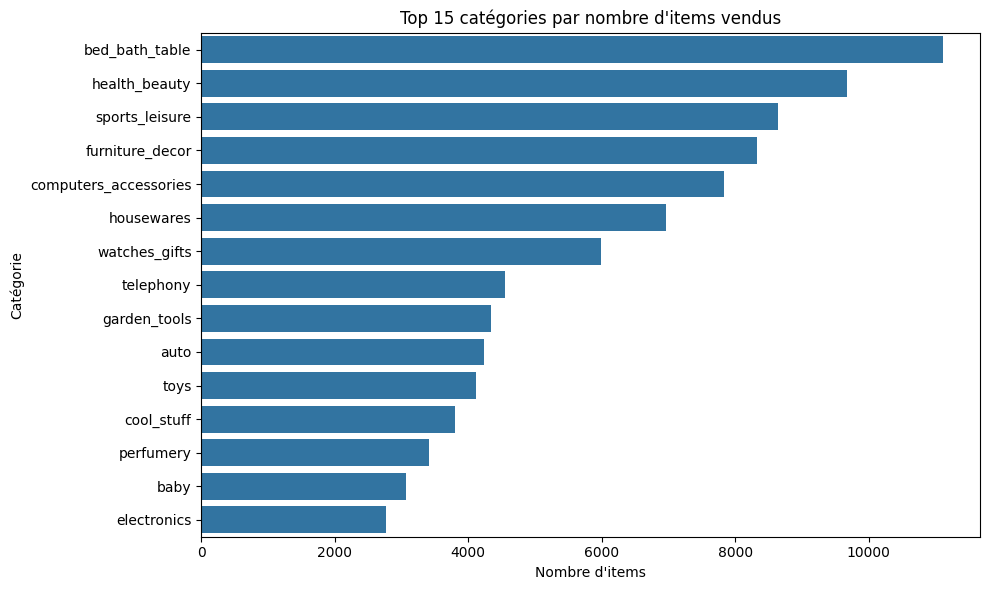

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_categories,
    y="product_category_name_english",
    x="items_count"
)
plt.title("Top 15 catégories par nombre d'items vendus")
plt.xlabel("Nombre d'items")
plt.ylabel("Catégorie")
plt.tight_layout()
plt.show()

## 8. Retards par État client

On regarde si certaines zones géographiques clients sont davantage associées aux retards de livraison.

In [23]:
customers = data["customers"].copy()

orders_customers = delivered_orders.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

delay_by_customer_state = (
    orders_customers
    .groupby("customer_state")
    .agg(
        orders_count=("order_id", "count"),
        late_rate=("late_delivery", "mean"),
        avg_delay_days=("delay_days", "mean")
    )
    .reset_index()
)

delay_by_customer_state["late_rate"] = delay_by_customer_state["late_rate"] * 100

delay_by_customer_state.sort_values("late_rate", ascending=False)

,customer_state,orders_count,late_rate,avg_delay_days
1,AL,397,21.410579,-8.707809
9,MA,717,17.433752,-9.571827
24,SE,335,15.223881,-10.020896
16,PI,476,13.865546,-11.306723
5,CE,1279,13.760751,-10.804535
21,RR,41,12.195122,-17.292683
4,BA,3256,12.162162,-10.794533
18,RJ,12350,12.105263,-11.761215
13,PA,946,11.205074,-14.066596
7,ES,1995,10.726817,-10.496241


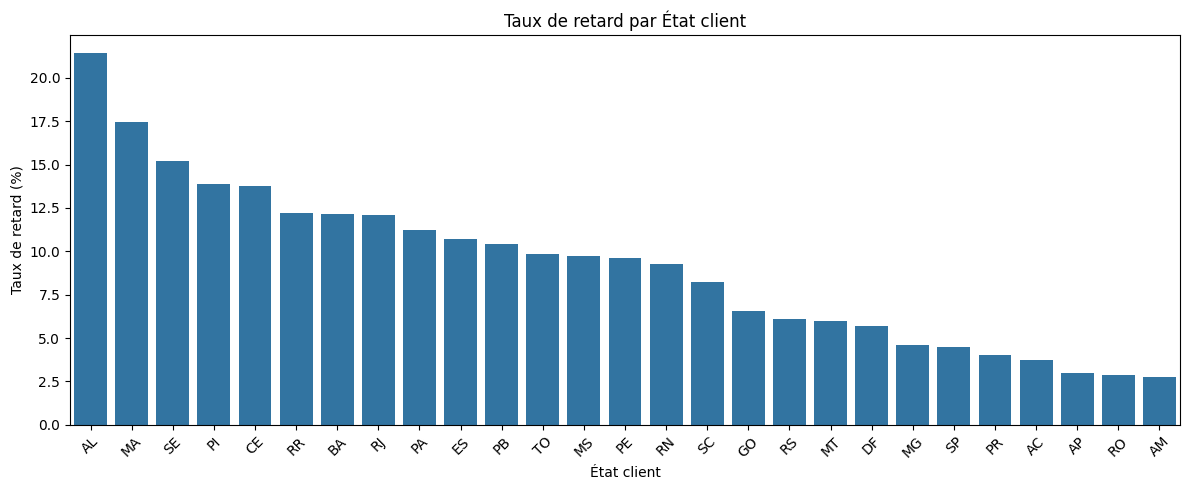

In [24]:
plt.figure(figsize=(12, 5))
sns.barplot(
    data=delay_by_customer_state.sort_values("late_rate", ascending=False),
    x="customer_state",
    y="late_rate"
)
plt.title("Taux de retard par État client")
plt.xlabel("État client")
plt.ylabel("Taux de retard (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Retards par vendeur

On analyse si certains vendeurs ont plus de retards.

Pour éviter les vendeurs avec trop peu de commandes, on filtre ici les vendeurs ayant au moins 50 commandes livrées.

In [25]:
sellers = data["sellers"].copy()

order_seller = order_items[["order_id", "seller_id"]].drop_duplicates()

orders_sellers = delivered_orders[["order_id", "late_delivery", "delay_days"]].merge(
    order_seller,
    on="order_id",
    how="left"
).merge(
    sellers[["seller_id", "seller_state"]],
    on="seller_id",
    how="left"
)

delay_by_seller = (
    orders_sellers
    .groupby(["seller_id", "seller_state"])
    .agg(
        orders_count=("order_id", "nunique"),
        late_rate=("late_delivery", "mean"),
        avg_delay_days=("delay_days", "mean")
    )
    .reset_index()
)

delay_by_seller["late_rate"] = delay_by_seller["late_rate"] * 100

top_risky_sellers = (
    delay_by_seller[delay_by_seller["orders_count"] >= 50]
    .sort_values("late_rate", ascending=False)
    .head(15)
)

top_risky_sellers

,seller_id,seller_state,orders_count,late_rate,avg_delay_days
1000,54965bbe3e4f07ae045b90b0b8541f52,PR,73,30.136986,-3.575342
2211,beadbee30901a7f61d031b6b686095ad,SP,64,23.437500,-9.453125
1928,a49928bcdf77c55c6d6e05e09a9b4ca5,SP,96,21.875000,-4.447917
1336,712e6ed8aa4aa1fa65dab41fed5737e4,SC,77,20.779221,-9.116883
79,06a2c3af7b3aee5d69171b0e14f0ee87,MA,389,19.023136,-11.367609
2,002100f778ceb8431b7a1020ff7ab48f,SP,50,18.000000,-8.180000
2720,ea566164622c6b439516ab18062c42cd,SP,50,18.000000,-8.100000
2365,cac4c8e7b1ca6252d8f20b2fc1a2e4af,SP,74,17.567568,-6.756757
1141,6039e27294dc75811c0d8a39069f52c0,SP,63,17.460317,-7.333333
1606,88460e8ebdecbfecb5f9601833981930,PR,246,17.073171,-11.182927


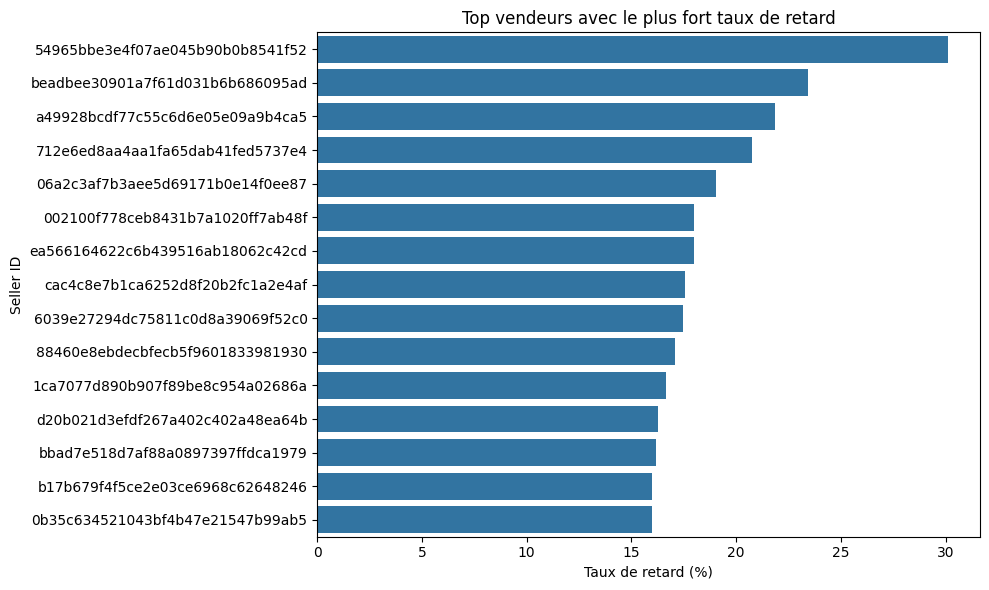

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_risky_sellers,
    y="seller_id",
    x="late_rate"
)
plt.title("Top vendeurs avec le plus fort taux de retard")
plt.xlabel("Taux de retard (%)")
plt.ylabel("Seller ID")
plt.tight_layout()
plt.show()

## 10. Premières variables target pour le ML

À partir de cette EDA rapide, on peut identifier les premières variables potentiellement utiles pour prédire le retard de livraison.

La target envisagée est :

`late_delivery = 1` si la commande est livrée après la date estimée, sinon `0`.

In [27]:
ml_candidates = pd.DataFrame([
    {"variable": "customer_state", "type": "catégorielle", "raison": "zone géographique du client"},
    {"variable": "seller_state", "type": "catégorielle", "raison": "zone géographique du vendeur"},
    {"variable": "product_category_name_english", "type": "catégorielle", "raison": "type de produit commandé"},
    {"variable": "price", "type": "numérique", "raison": "valeur du produit"},
    {"variable": "freight_value", "type": "numérique", "raison": "coût de livraison"},
    {"variable": "item_count", "type": "numérique", "raison": "complexité de la commande"},
    {"variable": "payment_type", "type": "catégorielle", "raison": "mode de paiement"},
    {"variable": "payment_installments", "type": "numérique", "raison": "nombre de mensualités"},
    {"variable": "estimated_delivery_days", "type": "numérique", "raison": "délai promis au client"},
    {"variable": "purchase_month", "type": "temporelle", "raison": "effet saisonnalité"},
    {"variable": "purchase_dayofweek", "type": "temporelle", "raison": "effet jour d'achat"},
])

ml_candidates

,variable,type,raison
0,customer_state,catégorielle,zone géographique du client
1,seller_state,catégorielle,zone géographique du vendeur
2,product_category_name_english,catégorielle,type de produit commandé
3,price,numérique,valeur du produit
4,freight_value,numérique,coût de livraison
5,item_count,numérique,complexité de la commande
6,payment_type,catégorielle,mode de paiement
7,payment_installments,numérique,nombre de mensualités
8,estimated_delivery_days,numérique,délai promis au client
9,purchase_month,temporelle,effet saisonnalité


tableau récapitulatif des variables qu’on pense utiliser plus tard pour le modèle ML.